In [1]:
import os

# JAX XLA profiling 0.1
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.1"
# optional, also used elsewhere in hmfast:
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")


USE_GPU = True  # set False for CPU-only
if not USE_GPU:
    os.environ["JAX_PLATFORMS"] = "cpu"

# Enable XLA profiler hook (writes .profile output on exit/runs)

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

from hmfast.cosmology import Cosmology
from hmfast.halos import HaloModel
from hmfast.halos.profiles import DMBPressureProfile, DMBMatterProfile, NFWMatterProfile
from hmfast.tracers import tSZTracer, CMBLensingTracer

print("USE_GPU =", USE_GPU)
print("JAX devices:", jax.devices())
print("XLA_FLAGS:", os.environ.get("XLA_FLAGS"))

USE_GPU = True
JAX devices: [CudaDevice(id=0), CudaDevice(id=1)]
XLA_FLAGS: None


## Cosmology, halo model, grids

Modest grids keep interactive runtime reasonable; increase `nM` / `nz` / `nell` for production plots.

In [2]:
cosmo = Cosmology(emulator_set="lcdm:v1")
hm = HaloModel(cosmology=cosmo, hm_consistency=False)
assert hm.hm_consistency is False

h = float(cosmo.H0) / 100.0
m = jnp.logspace(12.5, 15.0, 24) / h   # physical Msun
z = jnp.linspace(0.05, 1.2, 16)
ell = jnp.logspace(np.log10(30.0), np.log10(3000.0), 40)
k_arr = jnp.logspace(-2.0, 1.0, 48)    # 1/Mpc (hmfast pk convention)
z_sk = 0.3  # redshift for S(k)

print(f"hm_consistency={hm.hm_consistency}, h={h:.3f}")
print(f"grids: nM={m.size}, nz={z.size}, nell={ell.size}, nk={k_arr.size}")

hm_consistency=False, h=0.680
grids: nM=24, nz=16, nell=40, nk=48


## Helpers

$D_\ell = \ell(\ell+1) C_\ell / (2\pi)$. Fiducial DMB defaults: `theta_ej_0=4`, `theta_co_0=0.1`, `log10_Mc0=14.83`, `mu_beta=0.21`.

In [3]:
FID = {
    "theta_ej_0": 4.0,
    "theta_co_0": 0.1,
    "log10_Mc0": 14.83,
    "mu_beta": 0.21,
}

SCANS = {
    r"$\theta_{ej,0}$": ("theta_ej_0", [2.0, 4.0, 6.0]),
    r"$\theta_{co,0}$": ("theta_co_0", [0.05, 0.1, 0.2]),
    r"$\log_{10} M_{c,0}$": ("log10_Mc0", [14.0, 14.83, 15.5]),
    r"$\mu_\beta$": ("mu_beta", [0.1, 0.21, 0.4]),
}


def to_dell(cl, ell_arr=ell):
    ell_arr = np.asarray(ell_arr)
    return ell_arr * (ell_arr + 1.0) * np.asarray(cl) / (2.0 * np.pi)


def make_tsz(**dmb_kwargs):
    return tSZTracer(
        profile=DMBPressureProfile(num_points_trapz_int=32, **dmb_kwargs)
    )

def cl_yy(tracer):
    c1 = hm.cl_1h(tracer, None, ell, m, z)
    c2 = hm.cl_2h(tracer, None, ell, m, z)
    return np.asarray(c1), np.asarray(c2), np.asarray(c1 + c2)


def pk_mm(tracer):
    """P(k,z) with shape (Nk, Nz)."""
    return np.asarray(
        hm.pk_1h(tracer, None, k_arr, m, z) + hm.pk_2h(tracer, None, k_arr, m, z)
    )

## Fiducial $D_\ell^{yy}$

finite: True   max D_ell: 1.6154528401457206e-13


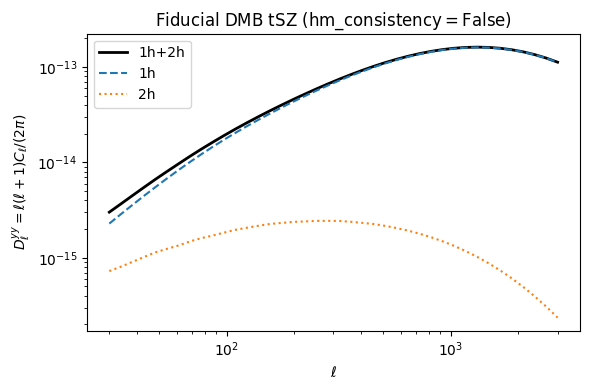

In [4]:
tsz_fid = make_tsz()
cl1_fid, cl2_fid, cl_fid = cl_yy(tsz_fid)
dl_fid = to_dell(cl_fid)
dl1_fid = to_dell(cl1_fid)
dl2_fid = to_dell(cl2_fid)

print("finite:", np.all(np.isfinite(dl_fid)), "  max D_ell:", float(np.max(dl_fid)))

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(ell, dl_fid, "k-", lw=2, label="1h+2h")
ax.loglog(ell, dl1_fid, "C0--", label="1h")
ax.loglog(ell, dl2_fid, "C1:", label="2h")
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$D_\ell^{yy}=\ell(\ell+1)C_\ell/(2\pi)$")
ax.set_title(r"Fiducial DMB tSZ ($\mathrm{hm\_consistency=False}$)")
ax.legend()
plt.tight_layout()
plt.show()

## Shape vs DMB parameters (absolute $D_\ell^{yy}$)

Each panel varies **one** parameter; others stay at defaults. Fiducial curve is the thick black line.

theta_ej_0=2.0: max D_ell=8.408e-13
theta_ej_0=4.0: max D_ell=1.615e-13


theta_ej_0=6.0: max D_ell=5.787e-14
theta_co_0=0.05: max D_ell=1.765e-13
theta_co_0=0.1: max D_ell=1.615e-13
theta_co_0=0.2: max D_ell=1.411e-13
log10_Mc0=14.0: max D_ell=2.399e-13
log10_Mc0=14.83: max D_ell=1.615e-13
log10_Mc0=15.5: max D_ell=1.222e-13
mu_beta=0.1: max D_ell=1.765e-13
mu_beta=0.21: max D_ell=1.615e-13
mu_beta=0.4: max D_ell=1.423e-13


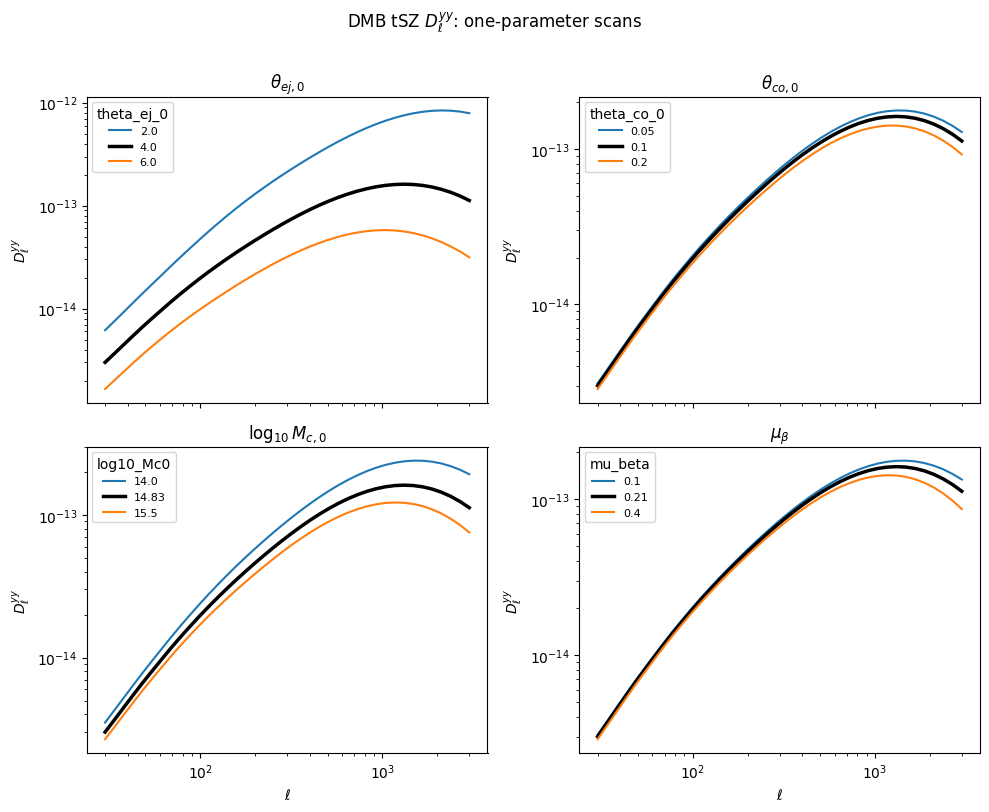

In [5]:
scan_cls = {}
for title, (key, values) in SCANS.items():
    curves = {}
    for v in values:
        _, _, cl = cl_yy(make_tsz(**{key: v}))
        curves[v] = cl
        print(f"{key}={v}: max D_ell={to_dell(cl).max():.3e}")
    scan_cls[key] = curves

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
for ax, (title, (key, values)) in zip(axes.ravel(), SCANS.items()):
    for v in values:
        is_fid = np.isclose(v, FID[key])
        ax.loglog(
            ell, to_dell(scan_cls[key][v]),
            color=("k" if is_fid else None),
            lw=(2.5 if is_fid else 1.5),
            label=f"{v}",
        )
    ax.set_title(title)
    ax.set_ylabel(r"$D_\ell^{yy}$")
    ax.legend(fontsize=8, title=key)
axes[1, 0].set_xlabel(r"$\ell$")
axes[1, 1].set_xlabel(r"$\ell$")
fig.suptitle(r"DMB tSZ $D_\ell^{yy}$: one-parameter scans", y=1.01)
plt.tight_layout()
plt.show()

## Shape response: $D_\ell / D_\ell^{\mathrm{fid}}$

Ratios highlight **shape** changes (not just overall amplitude). Same as $C_\ell/C_\ell^{\mathrm{fid}}$ because the $\ell(\ell+1)/(2\pi)$ prefactor cancels.

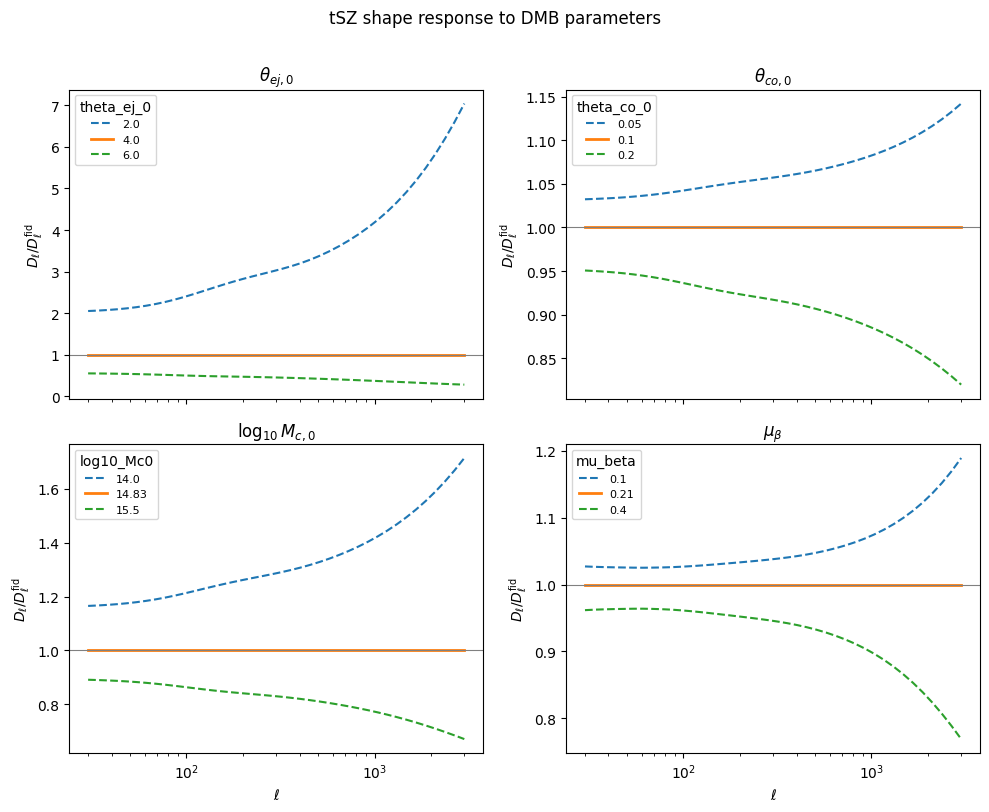

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
for ax, (title, (key, values)) in zip(axes.ravel(), SCANS.items()):
    for v in values:
        ratio = scan_cls[key][v] / cl_fid
        is_fid = np.isclose(v, FID[key])
        ax.semilogx(
            ell, ratio,
            ls=("-" if is_fid else "--"),
            lw=(2 if is_fid else 1.5),
            label=f"{v}",
        )
    ax.axhline(1.0, color="0.5", lw=0.8)
    ax.set_title(title)
    ax.set_ylabel(r"$D_\ell / D_\ell^{\mathrm{fid}}$")
    ax.legend(fontsize=8, title=key)
axes[1, 0].set_xlabel(r"$\ell$")
axes[1, 1].set_xlabel(r"$\ell$")
fig.suptitle(r"tSZ shape response to DMB parameters", y=1.01)
plt.tight_layout()
plt.show()

## Inferred PS suppression $S(k)=P_{\rm dmb}/P_{\rm nfw}$

Halo-model matter power from `DMBMatterProfile` vs `NFWMatterProfile` (via `CMBLensingTracer` wrappers for the `pk_*` API), evaluated at $z\approx 0.3$.

S(k) at z=0.280 (target 0.3)
theta_ej_0=2.0: S(k_max)=1.064
theta_ej_0=4.0: S(k_max)=1.034
theta_ej_0=6.0: S(k_max)=1.029
theta_co_0=0.05: S(k_max)=1.038
theta_co_0=0.1: S(k_max)=1.034
theta_co_0=0.2: S(k_max)=1.031
log10_Mc0=14.0: S(k_max)=1.044
log10_Mc0=14.83: S(k_max)=1.034
log10_Mc0=15.5: S(k_max)=1.030
mu_beta=0.1: S(k_max)=1.042
mu_beta=0.21: S(k_max)=1.034
mu_beta=0.4: S(k_max)=1.029


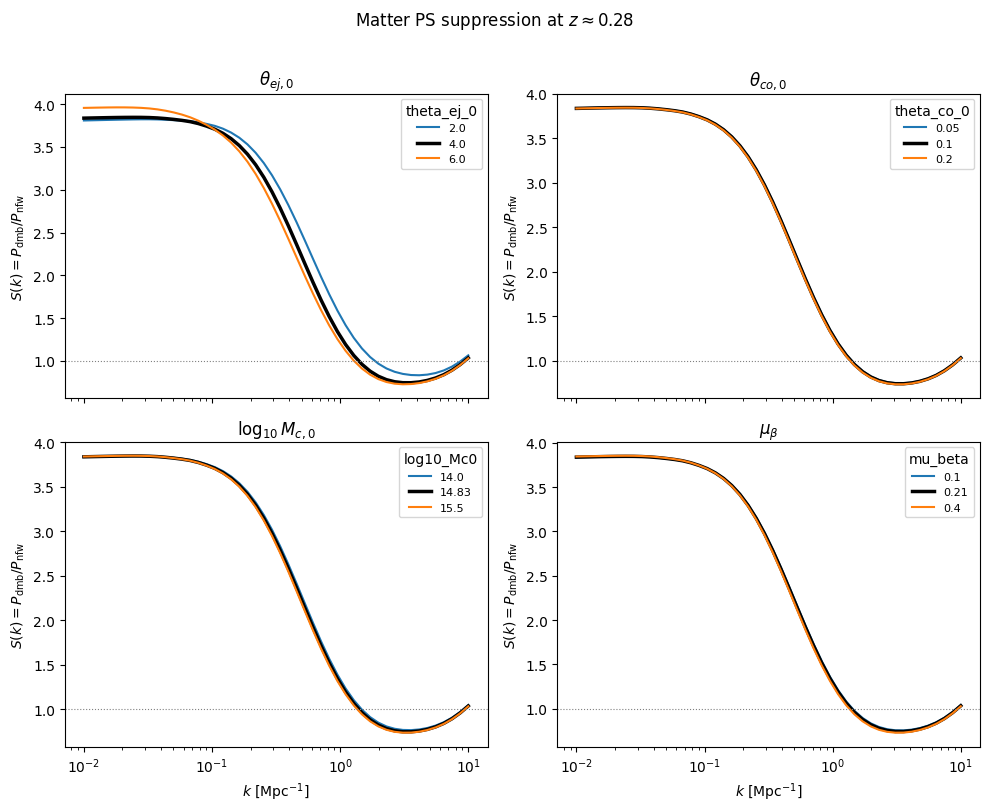

In [7]:
lens_nfw = CMBLensingTracer(profile=NFWMatterProfile())
pk_nfw = pk_mm(lens_nfw)
zi = int(np.argmin(np.abs(np.asarray(z) - z_sk)))
print(f"S(k) at z={float(z[zi]):.3f} (target {z_sk})")

scan_Sk = {}
for title, (key, values) in SCANS.items():
    curves = {}
    for v in values:
        tr = CMBLensingTracer(
            profile=DMBMatterProfile(num_points_trapz_int=32, **{key: v})
        )
        pk = pk_mm(tr)
        S = pk[:, zi] / np.maximum(pk_nfw[:, zi], 1e-30)
        curves[v] = S
        print(f"{key}={v}: S(k_max)={float(S[-1]):.3f}")
    scan_Sk[key] = curves

fig, axes = plt.subplots(2, 2, figsize=(10, 8), sharex=True)
for ax, (title, (key, values)) in zip(axes.ravel(), SCANS.items()):
    for v in values:
        is_fid = np.isclose(v, FID[key])
        ax.semilogx(
            k_arr, scan_Sk[key][v],
            color=("k" if is_fid else None),
            lw=(2.5 if is_fid else 1.5),
            label=f"{v}",
        )
    ax.axhline(1.0, color="0.5", ls=":", lw=0.8)
    ax.set_title(title)
    ax.set_ylabel(r"$S(k)=P_{\rm dmb}/P_{\rm nfw}$")
    ax.legend(fontsize=8, title=key)
axes[1, 0].set_xlabel(r"$k$ [Mpc$^{-1}$]")
axes[1, 1].set_xlabel(r"$k$ [Mpc$^{-1}$]")
fig.suptitle(fr"Matter PS suppression at $z\approx {float(z[zi]):.2f}$", y=1.01)
plt.tight_layout()
plt.show()

## Takeaways

- Plot **$D_\ell^{yy}$**, not raw $C_\ell$, for CMB-style comparison.
- **$\theta_{ej,0}$** typically moves power most at high $\ell$ and drives the strongest small-scale $S(k)$ suppression.
- **$\theta_{co,0}$**, **$\log_{10} M_{c,0}$**, and **$\mu_\beta$** reshape the core / mass-retention relation and shift both $D_\ell$ and $S(k)$.
- Keep **`hm_consistency=False`** for these tSZ / feedback-shape studies.

Related: `tsz_power_spectrum.ipynb`, `dmb_observables.ipynb`.